# ANÁLISIS DESAFÍO 3
**Proyecto:** Simulació Empresarial IT Academy — Bank Marketing  
**Equipo:** Analistas de Finanzas y Riesgo Crediticio  
**Pregunta:** *¿Qué umbrales de saldo podrían indicar más riesgo de morosidad?*

---
**Variables:** `balance` (numérica continua — saldo anual promedio en €) · `default` (binaria — crédito en mora: sí/no)  . `loan` (binaria — Prestamos: : sí/no) . housing ((binaria — Hipotecas: : sí/no) **Técnica:** Análisis Bivariado Segmentado 

- FASE 1: Carga y preparación de datos
- FASE 2: Análisis exploratorio descriptivo
- FASE 3: Segmentación por cuartiles
- FASE 4: Validación estadística (Chi-cuadrado + Mann-Whitney U)
- FASE 5: Validación de robustez por tipo de deuda
- FASE 6: Análisis complementario — CART (opcional)
- FASE 7: Análisis complementario — Regresión Logística (opcional)
- FASE 8: Resumen ejecutivo de resultados

### IMPORTACIÓN DE LIBRERÍAS

In [608]:
import pandas as pd                          # Manipulación de dataframes
import numpy as np                           # Operaciones numéricas
import matplotlib.pyplot as plt              # Visualizaciones básicas
import seaborn as sns                        # Visualizaciones estadísticas avanzadas
from scipy.stats import chi2_contingency     # Test Chi-cuadrado (asociación entre variables categóricas)
from scipy.stats import mannwhitneyu         # Test Mann-Whitney U (comparar distribuciones no paramétricas)
from scipy import stats                      # Funciones estadísticas adicionales
from sklearn.tree import DecisionTreeClassifier  # CART (árbol de decisión)
from sklearn.linear_model import LogisticRegression  # Regresión logística
from sklearn.metrics import classification_report, roc_auc_score  # Métricas de evaluación
import warnings                              # Controlar mensajes de advertencia
import statsmodels.api as sm

In [609]:
# Configuración de visualización
sns.set_style("whitegrid")                   # Estilo de gráficos limpio
warnings.filterwarnings('ignore')            # Ocultar warnings innecesarios (solo en producción)
pd.set_option('display.max_columns', None)   # Mostrar todas las columnas al imprimir dataframes

### 1. CARGA Y PREPARACION DE DATOS

In [610]:
df = pd.read_parquet("df_limpiado_260504.parquet")

In [611]:
df = df.reset_index()
#df

In [612]:
#df_powerbi = df.reset_index()
#df_powerbi.to_csv("df_limpiado_260511.csv", index=False)

In [613]:
# Variables de interes
variables = ['balance', 'default', 'housing', 'loan', 'age', 'marital', 'job']

##### --- 1.4 Limpieza y preparación de variables objetivo ---

In [614]:
# Ver valores únicos de 'default' antes de transformar
df['default'].unique()

<StringArray>
['no', 'yes']
Length: 2, dtype: string

In [615]:
df['default'].value_counts()

default
no     10994
yes      168
Name: count, dtype: Int64

In [616]:
# Convertir 'default' a variable binaria numérica (0 = no, 1 = yes)
df['default_num'] = (df['default'] == 'yes').astype(int)
df['default_num'].value_counts()

default_num
0    10994
1      168
Name: count, dtype: int64

In [617]:
df[variables].isnull().sum()

balance    0
default    0
housing    0
loan       0
age        0
marital    0
job        0
dtype: int64

In [618]:
# Calcular estadísticos básicos de 'balance' (necesarios para justificación técnica)
df['balance'].describe()

count    11162.000000
mean      1528.538524
std       3225.413326
min      -6847.000000
25%        122.000000
50%        550.000000
75%       1708.000000
max      81204.000000
Name: balance, dtype: float64

In [619]:
# Asimetria de Balance (Valor > 1 indica distribución fuertemente asimétrica)
df['balance'].skew()

8.224619112755489

### 2. ANÁLISIS EXPLORATORIO DESCRIPTIVO

##### 2.1 Distribución de la variable objetivo (default) ---

In [620]:
# Calcular tasa global de mora
tasa_mora_global = (df['default_num'].sum() / len(df)) * 100

In [621]:
exploracion_mora = {
    'Total clientes': len(df),
    'Clientes_mora': df['default_num'].sum(),
    'Tasa mora global': tasa_mora_global
    }
exploracion_mora
# Imprimir estadísticos formateados
for stat, value in exploracion_mora.items():
    if 'Tasa' in stat:
        # Formato de porcentaje con 2 decimales
        print(f"{stat:.<30} {value:.2%}")
    elif isinstance(value, int):
        # Formato de números enteros con separador de miles
        print(f"{stat:.<30} {value:,}")
    else:
        # Formato general para otros valores numéricos
        print(f"{stat:.<30} {value:,.2f}")
print(f"Solo el {tasa_mora_global:.2f}% de los clientes están en mora.")

Total clientes................ 11,162
Clientes_mora................. 168.00
Tasa mora global.............. 150.51%
Solo el 1.51% de los clientes están en mora.


##### 2.2 Estadísticos descriptivos de 'balance' ---

In [622]:
exploracion_balance={
    'Media': df['balance'].mean(),
    'Mediana (P50)': df['balance'].median(),
    'Desviación Estándar': df['balance'].std(),
    'Mínimo': df['balance'].min(),
    'P25 (Cuartil 1)': df['balance'].quantile(0.25),
    'P50 (Mediana)': df['balance'].quantile(0.50),
    'P75 (Cuartil 3)': df['balance'].quantile(0.75),
    'Máximo': df['balance'].max(),
    'Asimetría': df['balance'].skew()
}

#resultado_tabla = pd.Series(exploracion)
#print(resultado_tabla)
# Imprimir estadísticos formateados
for stat, value in exploracion_balance.items():
    if 'Asimetría' in stat:
        print(f"{stat:.<30} {value:.2f}")
    else:
        print(f"{stat:.<30} {value:,.2f} €")

Media......................... 1,528.54 €
Mediana (P50)................. 550.00 €
Desviación Estándar........... 3,225.41 €
Mínimo........................ -6,847.00 €
P25 (Cuartil 1)............... 122.00 €
P50 (Mediana)................. 550.00 €
P75 (Cuartil 3)............... 1,708.00 €
Máximo........................ 81,204.00 €
Asimetría..................... 8.22


In [623]:
print(f"   • Asimetría = {exploracion_balance['Asimetría']:.2f} (muy superior a 1)")
print(f"   • Conclusión: Distribución FUERTEMENTE SESGADA a la derecha")
print(f"   → Justifica uso de PERCENTILES/CUARTILES en vez de media ± desv.std")

   • Asimetría = 8.22 (muy superior a 1)
   • Conclusión: Distribución FUERTEMENTE SESGADA a la derecha
   → Justifica uso de PERCENTILES/CUARTILES en vez de media ± desv.std


In [624]:
# Cálculo de diferencia entre media y mediana (argumento clave para justificación técnica)
diferencia_pct = ((exploracion_balance['Media'] - exploracion_balance['P50 (Mediana)']) / exploracion_balance['P50 (Mediana)']) * 100
print(f"   • Media ({exploracion_balance['Media']:,.0f}€) es {diferencia_pct:.1f}% mayor que mediana ({exploracion_balance['P50 (Mediana)']:,.0f}€)")

   • Media (1,529€) es 177.9% mayor que mediana (550€)


##### 2.3 Distribución de saldo por estado de mora 

In [625]:
# Agrupar por estado de mora y calcular estadísticos
balance_por_mora = df.groupby('default')['balance'].agg([
    ('n_clientes', 'count'),
    ('mediana', 'median'),
    ('media', 'mean'),
    ('p25', lambda x: x.quantile(0.25)),
    ('p75', lambda x: x.quantile(0.75))
]).round(2)

print(balance_por_mora)


         n_clientes  mediana    media    p25     p75
default                                             
no            10994    564.5  1552.84  132.0  1735.0
yes             168      0.0   -61.80 -344.0    65.5


In [626]:
# Extraer valores para comparación
mediana_sin_mora = balance_por_mora.loc['no', 'mediana']
mediana_con_mora = balance_por_mora.loc['yes', 'mediana']
diferencia_mediana = mediana_sin_mora - mediana_con_mora
pct_diferencia = (diferencia_mediana / mediana_sin_mora) * 100

#### 2.4 Variables creadas adicionales

In [627]:
# Variable binaria: ¿tiene alguna deuda activa?
df['tiene_deuda'] = np.where(
    (df['housing'] == 'yes') | (df['loan'] == 'yes'),
    'Con Deuda',
    'Sin Deuda'
)

In [628]:
df.loc[(df['loan'] == 'no') & (df['housing'] == 'no'), 'grupo_deuda'] = 'Sin deuda'
df.loc[(df['loan'] == 'no') & (df['housing'] == 'yes'), 'grupo_deuda'] = 'Solo hipoteca'
df.loc[(df['loan'] == 'yes') & (df['housing'] == 'no'), 'grupo_deuda'] = 'Solo préstamo'
df.loc[(df['loan'] == 'yes') & (df['housing'] == 'yes'), 'grupo_deuda'] = 'Ambas deudas'


In [629]:
# Segmentación de saldo (continuidad con Reto 1)
p33, p66 = df['balance'].quantile([0.33, 0.66])

df['balance_cat'] = pd.cut(
    df['balance'],
    bins=[-np.inf, p33, p66, np.inf],
    labels=['bajo', 'medio', 'alto']
)

In [630]:
# Conteo de casos por grupo
print("\nDistribución de deuda:")
print(df['tiene_deuda'].value_counts())

print("\nDistribución de impago:")
print(df['default'].value_counts())

print("\nDistribución de prestamo:")
print(df['loan'].value_counts())

print("\nDistribución de hipoteca:")
print(df['housing'].value_counts())

print("\nDistribución de grupo de deuda:")
print(df['grupo_deuda'].value_counts())


Distribución de deuda:
tiene_deuda
Con Deuda    5906
Sin Deuda    5256
Name: count, dtype: int64

Distribución de impago:
default
no     10994
yes      168
Name: count, dtype: Int64

Distribución de prestamo:
loan
no     9702
yes    1460
Name: count, dtype: Int64

Distribución de hipoteca:
housing
no     5881
yes    5281
Name: count, dtype: Int64

Distribución de grupo de deuda:
grupo_deuda
Sin deuda        5256
Solo hipoteca    4446
Ambas deudas      835
Solo préstamo     625
Name: count, dtype: int64


### 3. SEGMENTACIÓN POR CUARTILES Y USANDO CART

- ### POR CUARTILES

#### 3.1 Cálculo de cuartiles y creación de categorías ---

In [631]:
# Calcular los 3 cuartiles que dividen en 4 grupos
q25 = df['balance'].quantile(0.25)
q50 = df['balance'].quantile(0.50)  # Equivalente a la mediana
q75 = df['balance'].quantile(0.75)

print(f"P25 (Cuartil 1): {q25:,.2f} €")
print(f"P50 (Cuartil 2 / Mediana): {q50:,.2f} €")
print(f"P75 (Cuartil 3): {q75:,.2f} €")

print(f"\n Estos valores dividen el saldo en 4 grupos de igual tamaño:")
print(f"   • Grupo 1 (Muy Bajo):  saldo ≤ {q25:,.0f}€")
print(f"   • Grupo 2 (Bajo):      {q25:,.0f}€ < saldo ≤ {q50:,.0f}€")
print(f"   • Grupo 3 (Medio):     {q50:,.0f}€ < saldo ≤ {q75:,.0f}€")
print(f"   • Grupo 4 (Alto):      saldo > {q75:,.0f}€")

P25 (Cuartil 1): 122.00 €
P50 (Cuartil 2 / Mediana): 550.00 €
P75 (Cuartil 3): 1,708.00 €

 Estos valores dividen el saldo en 4 grupos de igual tamaño:
   • Grupo 1 (Muy Bajo):  saldo ≤ 122€
   • Grupo 2 (Bajo):      122€ < saldo ≤ 550€
   • Grupo 3 (Medio):     550€ < saldo ≤ 1,708€
   • Grupo 4 (Alto):      saldo > 1,708€


##### 3.2 Crear variable categórica 'balance_cuartil' ---

In [632]:
# cuartiles
df['balance_cuartil'] = pd.cut(
    df['balance'],
    bins=[-np.inf, q25, q50, q75, np.inf],  # Límites de los intervalos
    labels=['Muy Bajo', 'Bajo', 'Medio', 'Alto'],  # Etiquetas
    include_lowest=True  # Incluir valor mínimo en primer intervalo
)

print(f"\nDistribución de clientes por cuartil:")
print(df['balance_cuartil'].value_counts().sort_index())


Distribución de clientes por cuartil:
balance_cuartil
Muy Bajo    2792
Bajo        2791
Medio       2789
Alto        2790
Name: count, dtype: int64


In [633]:
# Verificar que los grupos están balanceados (requisito del método)
tamaños_grupos = df['balance_cuartil'].value_counts()
cv_tamaño = (tamaños_grupos.std() / tamaños_grupos.mean()) * 100

print(f"\n VALIDACIÓN DE SUPUESTO: Tamaño de muestra suficiente")
print(f"   • Tamaño mínimo de grupo: {tamaños_grupos.min():,} clientes")
print(f"   • Tamaño máximo de grupo: {tamaños_grupos.max():,} clientes")
print(f"   • Coeficiente de variación: {cv_tamaño:.2f}%")
print(f"   → Grupos bien balanceados (CV < 5% indica equilibrio)")


 VALIDACIÓN DE SUPUESTO: Tamaño de muestra suficiente
   • Tamaño mínimo de grupo: 2,789 clientes
   • Tamaño máximo de grupo: 2,792 clientes
   • Coeficiente de variación: 0.05%
   → Grupos bien balanceados (CV < 5% indica equilibrio)


##### 3.3 Tasa de mora por cuartil ---

In [634]:
# Agrupar por cuartil y calcular métricas clave
mora_por_cuartil = df.groupby('balance_cuartil').agg(
    n_clientes=('default_num', 'count'), 
    n_mora=('default_num', 'sum'),        
    tasa_mora=('default_num', lambda x: (x.sum() / x.count()) * 100), 
    saldo_mediano=('balance', 'median'),      
    saldo_medio=('balance', 'mean')          
).round(2)

In [635]:
# Ordenar por cuartil (Muy Bajo → Alto)
mora_por_cuartil = mora_por_cuartil.reindex(['Muy Bajo', 'Bajo', 'Medio', 'Alto'])
print(mora_por_cuartil)

                 n_clientes  n_mora  tasa_mora  saldo_mediano  saldo_medio
balance_cuartil                                                           
Muy Bajo               2792     137       4.91            0.0       -54.30
Bajo                   2791      17       0.61          300.0       311.11
Medio                  2789      12       0.43          952.0      1012.10
Alto                   2790       2       0.07         3343.0      4846.63


In [636]:
print(f"\n HALLAZGO PRINCIPAL:")
tasa_muy_bajo = mora_por_cuartil.loc['Muy Bajo', 'tasa_mora']
tasa_alto = mora_por_cuartil.loc['Alto', 'tasa_mora']
ratio_riesgo = tasa_muy_bajo / tasa_alto if tasa_alto > 0 else np.inf

print(f"   • Tasa de mora en cuartil 'Muy Bajo': {tasa_muy_bajo:.2f}%")
print(f"   • Tasa de mora en cuartil 'Alto': {tasa_alto:.2f}%")
print(f"   • Ratio de riesgo: {ratio_riesgo:.1f}x")
print(f"   → Los clientes del cuartil inferior tienen {ratio_riesgo:.1f} VECES MÁS RIESGO")
print(f"     de impago que los del cuartil superior")


 HALLAZGO PRINCIPAL:
   • Tasa de mora en cuartil 'Muy Bajo': 4.91%
   • Tasa de mora en cuartil 'Alto': 0.07%
   • Ratio de riesgo: 70.1x
   → Los clientes del cuartil inferior tienen 70.1 VECES MÁS RIESGO
     de impago que los del cuartil superior


In [637]:
# Verificar relación monotónica (requisito metodológico)
print(f"\n VALIDACIÓN DE SUPUESTO: Relación monotónica")
tasas_ordenadas = mora_por_cuartil['tasa_mora'].tolist()
es_monotonica = all(tasas_ordenadas[i] >= tasas_ordenadas[i+1] for i in range(len(tasas_ordenadas)-1))

if es_monotonica:
    print(f" La tasa de mora DISMINUYE consistentemente al aumentar el saldo")
    print(f"      ({' → '.join([f'{t:.2f}%' for t in tasas_ordenadas])})")
    print(f"   → Relación monotónica CONFIRMADA")
else:
    print(f" Hay reversiones en la tendencia (analizar en detalle)")


 VALIDACIÓN DE SUPUESTO: Relación monotónica
 La tasa de mora DISMINUYE consistentemente al aumentar el saldo
      (4.91% → 0.61% → 0.43% → 0.07%)
   → Relación monotónica CONFIRMADA


- ### ANALISIS COMPLEMENTARIO: usando CART

##### PASO 1: Preparar datos

In [638]:
#df['default_bin'] = df['default'].map({'yes': 1, 'no': 0})

X = df[['balance']]          # variable explicativa
y = df['default_num']        # variable objetivo

##### PASO 2: Entrenar el árbol

In [639]:
tree = DecisionTreeClassifier(
    max_depth=3,           # controla complejidad
    min_samples_leaf=200   # evita ruido
)

tree.fit(X, y)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=200)

##### PASO 3: Extraer los puntos de corte

In [640]:
thresholds = tree.tree_.threshold
thresholds = thresholds[thresholds != -2]  # elimina hojas

thresholds = sorted(thresholds)
print(thresholds)

[-336.5, -107.5, -0.5, 17.5, 86.5, 1238.5]


##### PASO 4: Crear segmentos con esos cortes

In [641]:
df['segmento_cart'] = pd.cut(
    df['balance'],
    bins=[-np.inf] + thresholds + [np.inf],
    labels=['Muy bajo', 'Bajo negativo', 'Cercano a cero', 'Bajo positivo', 'Medio', 'Medio-alto','Alto']
)

##### PASO 5: Tasa de mora por segmento CART

In [642]:
# Agrupar por segmento y calcular métricas clave
mora_por_segmento_CART = df.groupby('segmento_cart').agg(
    n_clientes=('default_num', 'count'), 
    n_mora=('default_num', 'sum'),        
    tasa_mora=('default_num', lambda x: (x.sum() / x.count()) * 100), 
    saldo_mediano=('balance', 'median'),      
    saldo_medio=('balance', 'mean')          
).round(2)

In [643]:
# Ordenar por segmento (Muy Bajo → Alto)
mora_por_segmento_CART = mora_por_segmento_CART.reindex(['Muy bajo', 'Bajo negativo', 'Cercano a cero', 'Bajo positivo', 'Medio', 'Medio-alto','Alto'])
print(mora_por_segmento_CART)

                n_clientes  n_mora  tasa_mora  saldo_mediano  saldo_medio
segmento_cart                                                            
Muy bajo               245      44      17.96         -504.0      -657.46
Bajo negativo          235      14       5.96         -215.0      -221.85
Cercano a cero         208      20       9.62          -42.0       -45.99
Bajo positivo         1086      38       3.50            0.0         1.92
Medio                  690      18       2.61           50.0        50.59
Medio-alto            5152      31       0.60          439.0       508.85
Alto                  3546       3       0.08         2749.0      4124.58


### **Importante:** 
#### A diferencia de la segmentación por percentiles, el árbol de decisión genera grupos no equilibrados, ya que prioriza la identificación de diferencias en el riesgo

#### - CUARTIL VS. CART

Los **cuartiles** se usan como base del análisis por su claridad, equilibrio de grupos y facilidad de comunicación a gerencia. El **CART** actúa como validación complementaria, confirmando que el patrón detectado (menor saldo → mayor riesgo) es robusto incluso cuando se optimizan los cortes mediante aprendizaje supervisado. Ambos métodos convergen en el mismo hallazgo: **la liquidez es un predictor fuerte del riesgo de impago**.

### 4. VALIDACIÓN ESTADÍSTICA (CHI-CUADRADO + MANN-WHITNEY U)

##### 4.1 Test Chi-cuadrado: Asociación entre cuartil y mora 


- Hipótesis nula (H0): NO hay asociación entre cuartil de saldo y mora
- Hipótesis alternativa (H1): SÍ existe asociación

In [644]:
# Crear tabla de contingencia (cuartil vs. mora)
tabla_contingencia = pd.crosstab(df['balance_cuartil'], df['default_num'])

print(tabla_contingencia)

default_num         0    1
balance_cuartil           
Muy Bajo         2655  137
Bajo             2774   17
Medio            2777   12
Alto             2788    2


In [645]:
# Obtener los conteos de forma eficiente
conteo_chi = df.groupby(['balance_cuartil', 'default_num']).size().unstack(fill_value=0)

# Aplicar el test directamente sobre el objeto de conteo
chi2, p_valor_chi, dof, ex = chi2_contingency(conteo_chi.values)

print(f"Estadístico χ²: {chi2:.3f} | p-valor: {p_valor_chi:.6f}")

Estadístico χ²: 293.463 | p-valor: 0.000000


In [646]:
# Interpretación según nivel de significancia
alpha = 0.05
if p_valor_chi < alpha:
    print(f"\n CONCLUSIÓN (α = {alpha}):")
    print(f"   p-valor ({p_valor_chi:.6f}) < {alpha}")
    print(f"   → RECHAZAMOS H0")
    print(f"   → Existe asociación ESTADÍSTICAMENTE SIGNIFICATIVA entre cuartil y mora")
else:
    print(f"\n CONCLUSIÓN (α = {alpha}):")
    print(f"   p-valor ({p_valor_chi:.6f}) ≥ {alpha}")
    print(f"   → NO rechazamos H0")
    print(f"   → NO hay evidencia suficiente de asociación")

# Verificar supuesto del test (frecuencias esperadas > 5)
if ex.min() >= 5:
    print(f"\n Supuesto del test cumplido: frecuencias esperadas ≥ 5")
else:
    print(f"\n ADVERTENCIA: Frecuencia esperada mínima < 5")
    print(f"   → Considerar usar test exacto de Fisher")


 CONCLUSIÓN (α = 0.05):
   p-valor (0.000000) < 0.05
   → RECHAZAMOS H0
   → Existe asociación ESTADÍSTICAMENTE SIGNIFICATIVA entre cuartil y mora

 Supuesto del test cumplido: frecuencias esperadas ≥ 5


#### 4.2 Test Mann-Whitney U: Diferencia de distribuciones 

- Hipótesis nula (H0): Las distribuciones de saldo son iguales entre clientes CON y SIN mora
- Hipótesis alternativa (H1): Las distribuciones son diferentes

In [647]:
# Separar saldos por estado de mora
saldo_sin_mora = df[df['default'] == 'no']['balance']
saldo_con_mora = df[df['default'] == 'yes']['balance']

In [648]:
# Aplicar test Mann-Whitney U
u_stat, p_valor_mw = mannwhitneyu(saldo_sin_mora, saldo_con_mora, alternative='two-sided')

print(f"Tamaños de muestra:")
print(f"   • Sin mora: {len(saldo_sin_mora):,} clientes")
print(f"   • Con mora: {len(saldo_con_mora):,} clientes")
print(f"\nResultados del test:")
print(f"   • Estadístico U: {u_stat:,.0f}")
print(f"   • p-valor: {p_valor_mw:.6f}")


Tamaños de muestra:
   • Sin mora: 10,994 clientes
   • Con mora: 168 clientes

Resultados del test:
   • Estadístico U: 1,570,342
   • p-valor: 0.000000


In [649]:
# Comparar medianas
mediana_sin = saldo_sin_mora.median()
mediana_con = saldo_con_mora.median()
diferencia = mediana_sin - mediana_con

print(f"\nMedianas observadas:")
print(f"   • Sin mora: {mediana_sin:,.2f}€")
print(f"   • Con mora: {mediana_con:,.2f}€")
print(f"   • Diferencia: {diferencia:,.2f}€")

# Interpretación
if p_valor_mw < alpha:
    print(f"\n CONCLUSIÓN (α = {alpha}):")
    print(f"   p-valor ({p_valor_mw:.6f}) < {alpha}")
    print(f"   → RECHAZAMOS H0")
    print(f"   → Las distribuciones de saldo difieren SIGNIFICATIVAMENTE")
    print(f"   → Clientes con mora tienen saldo sistemáticamente MENOR")
else:
    print(f"\n CONCLUSIÓN (α = {alpha}):")
    print(f"   p-valor ({p_valor_mw:.6f}) ≥ {alpha}")
    print(f"   → NO rechazamos H0")


Medianas observadas:
   • Sin mora: 564.50€
   • Con mora: 0.00€
   • Diferencia: 564.50€

 CONCLUSIÓN (α = 0.05):
   p-valor (0.000000) < 0.05
   → RECHAZAMOS H0
   → Las distribuciones de saldo difieren SIGNIFICATIVAMENTE
   → Clientes con mora tienen saldo sistemáticamente MENOR


### 5. VALIDACIÓN DE ROBUSTEZ POR TIPO DE DEUDA
Objetivo: Verificar si los umbrales de saldo mantienen capacidad discriminatoria en distintos segmentos de deuda"

####  5.1 Segmentación por tipo de deuda ---

In [650]:
print("\nDistribución de grupo de deuda:")
print(df['grupo_deuda'].value_counts())


Distribución de grupo de deuda:
grupo_deuda
Sin deuda        5256
Solo hipoteca    4446
Ambas deudas      835
Solo préstamo     625
Name: count, dtype: int64


### 5.2 Análisis de saldo mediano por tipo de deuda ---

In [651]:
print("\n SALDO MEDIANO Y TASA DE MORA POR TIPO DE DEUDA:")
# Calcular métricas por grupo de deuda
resumen_deuda = df.groupby('grupo_deuda').agg(
    n_clientes=('default_num', 'count'),
    saldo_mediano=('balance', 'median'),
    saldo_medio=('balance', 'mean'),
    tasa_mora=('default_num', lambda x: (x.sum() / x.count()) * 100)
).round(2)

# Ordenar por nivel de riesgo (de mayor a menor mora)
resumen_deuda = resumen_deuda.sort_values('tasa_mora', ascending=False)

print(resumen_deuda)


 SALDO MEDIANO Y TASA DE MORA POR TIPO DE DEUDA:
               n_clientes  saldo_mediano  saldo_medio  tasa_mora
grupo_deuda                                                     
Solo préstamo         625          266.0       896.65       5.44
Ambas deudas          835          301.0       771.81       2.75
Solo hipoteca        4446          498.0      1358.99       1.44
Sin deuda            5256          697.0      1867.31       0.89


In [652]:
# Comparar con el umbral P50 global
print(f"\n VALIDACIÓN DEL SUPUESTO: Generalización de umbrales")
print(f"   Umbral P50 (mediana global): {q50:,.2f}€")
print()

for grupo in resumen_deuda.index:
    saldo_grupo = resumen_deuda.loc[grupo, 'saldo_mediano']
    tasa_grupo = resumen_deuda.loc[grupo, 'tasa_mora']
    posicion = "por debajo" if saldo_grupo < q50 else "por encima"
    
    print(f"   • {grupo:20s}: saldo = {saldo_grupo:6.0f}€ ({posicion} de P50), mora = {tasa_grupo:.2f}%")

print(f"\n CONCLUSIÓN:")
print(f"   Los segmentos con MAYOR MORA (Solo préstamo, Ambas deudas)")
print(f"   tienen saldo mediano POR DEBAJO del umbral P50.")
print(f"   → Los umbrales mantienen capacidad discriminatoria en distintos segmentos")


 VALIDACIÓN DEL SUPUESTO: Generalización de umbrales
   Umbral P50 (mediana global): 550.00€

   • Solo préstamo       : saldo =    266€ (por debajo de P50), mora = 5.44%
   • Ambas deudas        : saldo =    301€ (por debajo de P50), mora = 2.75%
   • Solo hipoteca       : saldo =    498€ (por debajo de P50), mora = 1.44%
   • Sin deuda           : saldo =    697€ (por encima de P50), mora = 0.89%

 CONCLUSIÓN:
   Los segmentos con MAYOR MORA (Solo préstamo, Ambas deudas)
   tienen saldo mediano POR DEBAJO del umbral P50.
   → Los umbrales mantienen capacidad discriminatoria en distintos segmentos


##### 5.3 Tabla cruzada: Cuartil × Tipo de deuda ---

In [653]:
print("\n DISTRIBUCIÓN CONJUNTA: CUARTIL × TIPO DE DEUDA:")

# Tabla de contingencia con porcentajes por fila
tabla_cuartil_deuda = pd.crosstab(
    df['balance_cuartil'],
    df['grupo_deuda'],
    normalize='index'  # Porcentaje por fila (suma 100% en cada cuartil)
) * 100

# Reordenar columnas por nivel de riesgo
orden_columnas = ['Solo préstamo', 'Ambas deudas', 'Solo hipoteca', 'Sin deuda']
tabla_cuartil_deuda = tabla_cuartil_deuda[orden_columnas]

print("Porcentaje de cada tipo de deuda dentro de cada cuartil:")
print(tabla_cuartil_deuda.round(1))


 DISTRIBUCIÓN CONJUNTA: CUARTIL × TIPO DE DEUDA:
Porcentaje de cada tipo de deuda dentro de cada cuartil:
grupo_deuda      Solo préstamo  Ambas deudas  Solo hipoteca  Sin deuda
balance_cuartil                                                       
Muy Bajo                   8.5          10.8           42.2       38.5
Bajo                       6.3           7.7           40.8       45.1
Medio                      4.5           7.4           41.0       47.1
Alto                       3.2           3.9           35.3       57.6


In [654]:
print(f"\n INTERPRETACIÓN:")
print(f"   En el cuartil 'Muy Bajo':")
pct_prestamo_bajo = tabla_cuartil_deuda.loc['Muy Bajo', 'Solo préstamo']
pct_prestamo_alto = tabla_cuartil_deuda.loc['Alto', 'Solo préstamo']
print(f"   • {pct_prestamo_bajo:.1f}% tienen solo préstamo")
print(f"   En el cuartil 'Alto':")
print(f"   • {pct_prestamo_alto:.1f}% tienen solo préstamo")
print(f"   → Los clientes con préstamo personal se CONCENTRAN en cuartiles bajos")


 INTERPRETACIÓN:
   En el cuartil 'Muy Bajo':
   • 8.5% tienen solo préstamo
   En el cuartil 'Alto':
   • 3.2% tienen solo préstamo
   → Los clientes con préstamo personal se CONCENTRAN en cuartiles bajos


### 6. ANALISIS COMPLEMENTARIO: Validación del riesgo mediante regresión logística (Logit)
Objetivo: validar y cuantificar la relación entre el nivel de saldo y el riesgo de impago.

##### Seleccionar variables

In [655]:
data = df[['default_num', 'balance_cuartil']]

In [656]:
orden = ['Muy bajo', 'Bajo', 'Medio', 'Alto']

data['balance_cuartil'] = pd.Categorical(
    df['balance_cuartil'],
    categories=orden,
    ordered=True
)

##### Crear variables dummy

In [657]:
X = pd.get_dummies(
    data[['balance_cuartil']],
    drop_first=True
)

##### Añadir constante y convertir a numerico

In [658]:
X = sm.add_constant(X)
X = X.astype(int)

##### Definir variable objetivo

In [659]:
y = data['default_num'].astype(int)

##### Entrenar modelo logit

In [660]:
model = sm.Logit(y, X).fit()

Optimization terminated successfully.
         Current function value: 0.066661
         Iterations 11


In [661]:
print(model.summary())

                           Logit Regression Results                           
Dep. Variable:            default_num   No. Observations:                11162
Model:                          Logit   Df Residuals:                    11158
Method:                           MLE   Df Model:                            3
Date:                Thu, 07 May 2026   Pseudo R-squ.:                  0.1464
Time:                        10:19:13   Log-Likelihood:                -744.07
converged:                       True   LL-Null:                       -871.71
Covariance Type:            nonrobust   LLR p-value:                 4.746e-55
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -2.9642      0.088    -33.833      0.000      -3.136      -2.793
balance_cuartil_Bajo     -2.1306      0.259     -8.240      0.000      -2.637      -1.624
balance_

#### Interpretacion resultados del modelo Logit **default ~ balance_cuartil**

Grupo de referencia: segmento **Muy bajo**

Todos los coeficientes son negativos:

- balance_cuartil_Bajo   = -2.13

- balance_cuartil_Medio  = -2.48

- balance_cuartil_Alto   = -4.27

significa que estos grupos tienen MENOR riesgo que el grupo **Muy bajo**

Patron : mayor saldo → menor riesgo

#### Interptretacion de **Odds Ratios** (El odds ratio permite medir cuánto aumenta o disminuye el riesgo respecto al grupo de referencia)

- ##### **Bajo**

##### OR = exp(-2.13) ≈ 0.12 : el riesgo es 0.12 veces el del grupo Muy bajo

##### Calculo: (1 - 0.12) × 100 = 0.88 × 100 = 88%

##### Grupo **Bajo** tiene aproximadamente un **88%** menos riesgo que el grupo de referencia.


- ##### **Medio**

##### OR = exp(-2.48) ≈ 0.084 : el riesgo es 0.084 veces el del grupo Muy bajo

##### Calculo: (1 - 0.084) × 100 = 0.916 × 100 = 91.6%

##### Grupo **Medio** tiene aproximadamente un **92%** menos riesgo que el grupo de referencia.

- ##### **Alto**
##### OR = exp(-4.28) ≈ 0.014 : el riesgo es 0.014 veces el del grupo Muy bajo

##### Calculo: (1 - 0.014) × 100 = 0.986 × 100 = 98,6%

##### Grupo **Alto** tiene aproximadamente un **99%** menos riesgo que el grupo de referencia.

##### Buen ajuste para logística: Pseudo R² = 0.146

##### El modelo logístico confirma que los clientes con menores niveles de saldo presentan un riesgo significativamente mayor de impago. Además, la presencia de préstamos incrementa notablemente este riesgo
| Variable           | Impacto            | Acción                 |
| ------------------ | ------------------ | ---------------------- |
| Saldo alto         | 🟢 reduce riesgo   | clientes objetivo      |
| Saldo medio        | 🟡 riesgo moderado | evaluación estándar    |
| Saldo bajo/crítico | 🔴 alto riesgo     | políticas restrictivas |
| Loan               | 🔴 aumenta riesgo  | scoring más estricto   |

# Visualizaciones

In [662]:
# Definición de colores 
azul_banca = "#002060" 
verde_banca = "#2BA86E"
gris_banca = "#A6A6A6"
gris_banca_oscuro = "#3F3838"
rojo_banca = "#A91C1CE2"
rojo_riesgo = "#C00000"

umbrales = [ 
    'MUY BAJO\n(≤ 122€)', 
    'BAJO\n(122€ - 550€)', 
    'MEDIO\n(550€ - 1.708€)', 
    'ALTO\n(> 1.708€)'
]

#### VISUALIZACIÓN 1: Grafico de barras de tasa de mora
muestra exactamente los umbrales (≤122€, 122-550€, 550-1,708€, >1,708€) en el eje X y la tasa de mora de cada segmento en el eje Y. La respuesta es visible de inmediato sin explicación.

In [663]:
data_vis = mora_por_cuartil.copy()
data_vis['umbrales'] = umbrales
data_vis

,n_clientes,n_mora,tasa_mora,saldo_mediano,saldo_medio,umbrales
balance_cuartil,,,,,,
Muy Bajo,2792,137,4.91,0.0,-54.30,MUY BAJO\n(≤ 122€)
Bajo,2791,17,0.61,300.0,311.11,BAJO\n(122€ - 550€)
Medio,2789,12,0.43,952.0,1012.10,MEDIO\n(550€ - 1.708€)
Alto,2790,2,0.07,3343.0,4846.63,ALTO\n(> 1.708€)


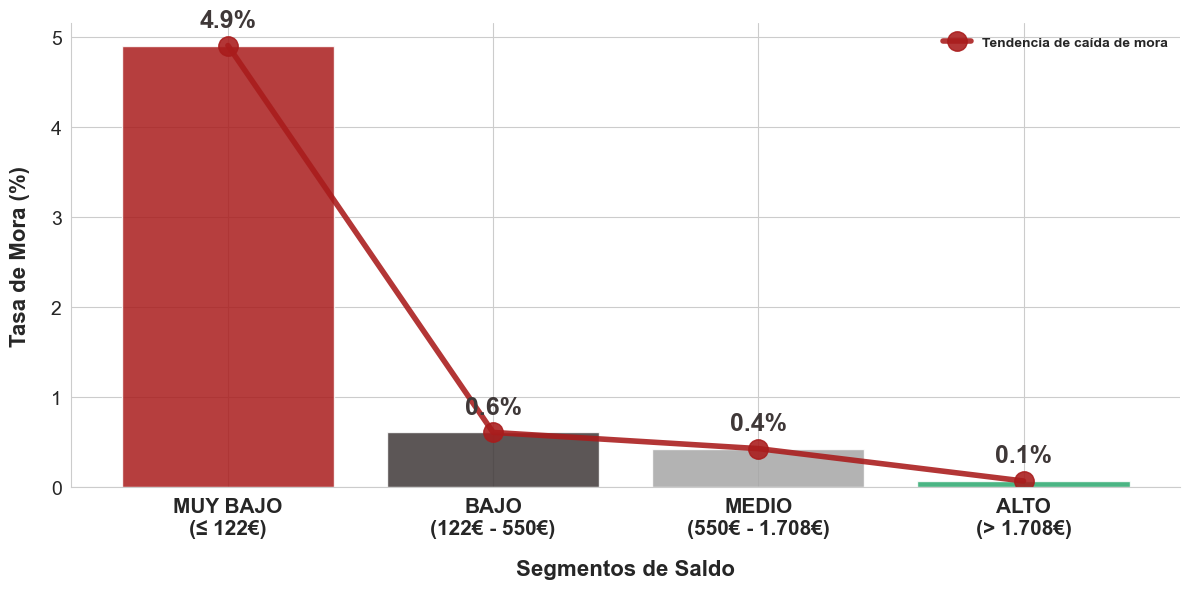

In [664]:
fig, ax = plt.subplots(figsize=(12, 6)) # MEJORA: Aumento leve de altura para aire visual

colores_barras = [rojo_banca, gris_banca_oscuro, gris_banca, verde_banca]
bars = ax.bar(data_vis['umbrales'], data_vis['tasa_mora'], color=colores_barras, alpha=0.85)


ax.plot(data_vis['umbrales'], data_vis['tasa_mora'], marker='o', color=rojo_banca, 
        linewidth=4, markersize=14, label='Tendencia de caída de mora')

# ETIQUETAS DE DATOS: 
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.15,
            f'{height:.1f}%', ha='center', va='bottom', 
            fontsize=18, fontweight='bold', color=gris_banca_oscuro)
    
# Leyenda de la linea
ax.legend(loc='upper right', fontsize=16, frameon=False, prop={'weight':'bold'})

# ESTÉTICA DE EJES: MEJORA: Tamaños para legibilidad a distancia
ax.set_ylabel('Tasa de Mora (%)', fontsize=16, fontweight='bold', labelpad=15)
ax.set_xlabel('Segmentos de Saldo', fontsize=16, fontweight='bold', labelpad=15)
plt.xticks(fontsize=15, fontweight='bold')
plt.yticks(fontsize=14)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('output/Finanzas_VIZ1_tasa_de_mora_vs_saldo_FINAL.png', dpi=300, bbox_inches='tight')
plt.show()

######## CALLOUT / ANOTACIÓN: NUEVO: El dato del "70x riesgo" pedido por la auditoría
ax.annotate('EL RIESGO SE MULTIPLICA 70x\nEN ESTE UMBRAL', 
            xy=(0, 4.5), xytext=(0.8, 4.8),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1),
            fontsize=14, fontweight='bold', color=rojo_riesgo, bbox=dict(boxstyle="round,pad=0.5", fc="white", ec=rojo_riesgo, alpha=0.9))

#### VISUALIZACIÓN 2: Heatmap de Matriz de Riesgo
no responde la pregunta principal — valida que los umbrales encontrados en VIZ 1 se sostienen en todos los tipos de deuda. Es evidencia de apoyo, no la respuesta.

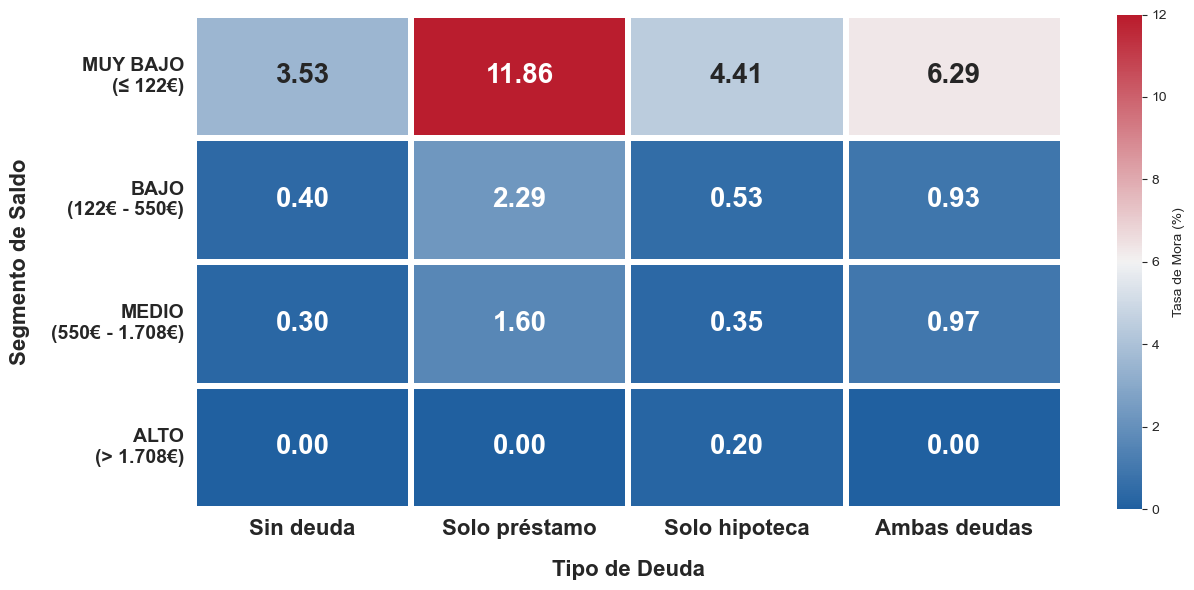

In [667]:


#  Invertir el orden para que "Muy Bajo" 
orden_filas_inv = ['Muy Bajo', 'Bajo', 'Medio', 'Alto'] 

pivot_mora = df.pivot_table(index='balance_cuartil', columns='grupo_deuda', 
                             values='default_num', aggfunc='mean') * 100
pivot_mora = pivot_mora.reindex(orden_filas_inv) # Aplicar inversión

# Nombres de columnas más ejecutivos
orden_columnas = ['Sin deuda', 'Solo préstamo', 'Solo hipoteca', 'Ambas deudas']
pivot_mora = pivot_mora.reindex(columns=orden_columnas)

pivot_mora.index = umbrales

fig, ax = plt.subplots(figsize=(13,6))

# Paleta de colores 
cmap = sns.diverging_palette(250, 10, s=90, l=40, n=9, as_cmap=True)

# MAPA DE CALOR:
sns.heatmap(pivot_mora, annot=True, fmt=".2f", cmap=cmap,
            cbar_kws={'label': 'Tasa de Mora (%)'},
            linewidths=3, linecolor='white',
            vmin=0, vmax=12,  
            square=False, ax=ax, 
            annot_kws={'fontsize': 20, 'fontweight': 'bold'})

# Títulos y etiquetas con tamaños de fuente para "última fila de la sala"
plt.xlabel('Tipo de Deuda', fontsize=16, fontweight='bold', labelpad=15)
plt.ylabel('Segmento de Saldo', fontsize=16, fontweight='bold', labelpad=15)

plt.xticks(rotation=0, fontsize=16, fontweight='bold') # MEJORA: Rotación 0 para leer sin girar la cabeza
plt.yticks(fontsize=14, fontweight='bold', rotation=0)

plt.tight_layout()
plt.savefig('output/Finanzas_VIZ2_Matriz_Riesgo_FINAL.png', dpi=300, bbox_inches='tight')
plt.show()

######### Texto de conclusión directa dentro de la imagen
plt.figtext(0.5, -0.05, "HALLAZGO: El préstamo personal en saldos bajos es el disparador crítico de mora (11.86%)", 
            ha="center", fontsize=14, bbox={"facecolor":"orange", "alpha":0.2, "pad":5}, fontweight='bold')